<a href="https://colab.research.google.com/github/ksmorozov7/Portfolio/blob/main/PySpark_EMP_DEPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PySpark

## Установка PySpark

In [ ]:
!pip install pyspark

## Инициализация Spark

In [ ]:
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    DateType,
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

## Старт сессии Spark

In [ ]:
spark = (
    SparkSession.builder.appName("PySpark_Learning")
    .master("local[*]")
    .getOrCreate()
)

## Данные для таблицы DEPT

In [ ]:
dept_data = [
    (10, "ACCOUNTING", "NEW YORK"),
    (20, "RESEARCH", "DALLAS"),
    (30, "SALES", "CHICAGO"),
    (40, "OPERATIONS", "BOSTON"),
]

dept_schema = StructType(
    [
        StructField("DEPTNO", IntegerType(), True),
        StructField("DNAME", StringType(), True),
        StructField("LOC", StringType(), True),
    ]
)

Spark DataFrame для отделов

In [ ]:
df_dept = spark.createDataFrame(dept_data, schema=dept_schema)

## Данные для таблицы EMP

In [ ]:
emp_data = [
    (7369, "SMITH", "CLERK", 7902, "17-DEC-1980", 800.0, None, 20),
    (7499, "ALLEN", "SALESMAN", 7698, "20-FEB-1981", 1600.0, 300.0, 30),
    (7521, "WARD", "SALESMAN", 7698, "22-FEB-1981", 1250.0, 500.0, 30),
    (7566, "JONES", "MANAGER", 7839, "02-APR-1981", 2975.0, None, 20),
    (7554, "MARTIN", "SALESMAN", 7698, "28-SEP-1981", 1250.0, 1400.0, 30),
    (7698, "BLAKE", "MANAGER", 7839, "01-MAY-1981", 2850.0, None, 30),
    (7782, "CLARK", "MANAGER", 7839, "09-JUN-1981", 2450.0, None, 10),
    (7788, "SCOTT", "ANALYST", 7566, "09-DEC-1982", 3000.0, None, 20),
    (7839, "KING", "PRESIDENT", None, "17-NOV-1981", 5000.0, None, 10),
    (7844, "TURNER", "SALESMAN", 7698, "08-SEP-1981", 1500.0, 0.0, 30),
    (7876, "ADAMS", "CLERK", 7788, "12-JAN-1983", 1100.0, None, 20),
    (7900, "JAMES", "CLERK", 7698, "03-DEC-1981", 950.0, None, 30),
    (7902, "FORD", "ANALYST", 7566, "03-DEC-1981", 3000.0, None, 20),
    (7934, "MILLER", "CLERK", 7782, "23-JAN-1982", 1300.0, None, 10),
]

emp_schema = StructType(
    [
        StructField("EMPNO", IntegerType(), True),
        StructField("ENAME", StringType(), True),
        StructField("JOB", StringType(), True),
        StructField("MGR", IntegerType(), True),
        StructField("HIREDATE", StringType(), True),
        StructField("SAL", DoubleType(), True),
        StructField("COMM", DoubleType(), True),
        StructField("DEPTNO", IntegerType(), True),
    ]
)


Spark DataFrame для сотрудников

In [ ]:
df_emp = spark.createDataFrame(emp_data, schema=emp_schema)

Преобразование строки с датой в правильный формат даты Spark

In [ ]:
from pyspark.sql.functions import to_date

In [ ]:
df_emp = df_emp.withColumn("HIREDATE", to_date("HIREDATE", "dd-MMM-yyyy"))

Регистрация как sql таблицы

In [ ]:
df_dept.createOrReplaceTempView("DEPT")
df_emp.createOrReplaceTempView("EMP")

print("Spark успешно запущен, таблицы EMP и DEPT готовы к работе!")

Spark успешно запущен, таблицы EMP и DEPT готовы к работе!


## Проверка связи (sql запрос)

In [ ]:
query = """
SELECT e.ENAME, e.JOB, d.DNAME, e.SAL
FROM EMP e
JOIN DEPT d ON e.DEPTNO = d.DEPTNO
WHERE e.SAL > 2000
"""

In [ ]:
spark.sql(query).show()

+-----+---------+----------+------+
|ENAME|      JOB|     DNAME|   SAL|
+-----+---------+----------+------+
|CLARK|  MANAGER|ACCOUNTING|2450.0|
| KING|PRESIDENT|ACCOUNTING|5000.0|
|JONES|  MANAGER|  RESEARCH|2975.0|
|SCOTT|  ANALYST|  RESEARCH|3000.0|
| FORD|  ANALYST|  RESEARCH|3000.0|
|BLAKE|  MANAGER|     SALES|2850.0|
+-----+---------+----------+------+



## Сравнение SQL и PySpark API (DataFrame API - синтаксис PySpark)

In [ ]:
# Импортируем функции для условий (например, для фильтрации)
from pyspark.sql.functions import col

# Делаем всё то же самое цепочкой методов
result_api = df_emp.alias("e") \
    .join(df_dept.alias("d"), col("e.DEPTNO") == col("d.DEPTNO"), "inner") \
    .filter(col("e.SAL") > 2000) \
    .select("e.ENAME", "e.JOB", "d.DNAME", "e.SAL")

# Выводим результат
result_api.show()


+-----+---------+----------+------+
|ENAME|      JOB|     DNAME|   SAL|
+-----+---------+----------+------+
|CLARK|  MANAGER|ACCOUNTING|2450.0|
| KING|PRESIDENT|ACCOUNTING|5000.0|
|JONES|  MANAGER|  RESEARCH|2975.0|
|SCOTT|  ANALYST|  RESEARCH|3000.0|
| FORD|  ANALYST|  RESEARCH|3000.0|
|BLAKE|  MANAGER|     SALES|2850.0|
+-----+---------+----------+------+



## Обычный sql запрс

In [ ]:
query_job = """
SELECT JOB,
       COUNT(*) as emp_count,
       SUM(SAL) as total_sal
FROM EMP
GROUP BY JOB
ORDER BY total_sal DESC
"""

In [ ]:
spark.sql(query_job).show()

+---------+---------+---------+
|      JOB|emp_count|total_sal|
+---------+---------+---------+
|  MANAGER|        3|   8275.0|
|  ANALYST|        2|   6000.0|
| SALESMAN|        4|   5600.0|
|PRESIDENT|        1|   5000.0|
|    CLERK|        4|   4150.0|
+---------+---------+---------+



## Метод .toPandas()

 В Spark встроен метод .toPandas(). Он берет результат распределенного SQL-запроса, превращает его в привычную таблицу Pandas, и Colab снова выводит её красиво.

Важное правило Big Data: метод .toPandas() можно использовать только для результатов запроса (например, после фильтрации или группировки), когда строк осталось не очень много (до пары сотен тысяч). Если попытаться превратить в Pandas миллиард строк, у ноутбука просто закончится оперативная память.


In [ ]:
query = '''SELECT * FROM DEPT'''

In [ ]:
spark.sql(query).toPandas()

,DEPTNO,DNAME,LOC
0,10,ACCOUNTING,NEW YORK
1,20,RESEARCH,DALLAS
2,30,SALES,CHICAGO
3,40,OPERATIONS,BOSTON


# Датасет про бирилианты (около 100 000+ строк)

## Скачиваю csv с транзакциям

In [ ]:
import seaborn as sns

# Загружаем датасет из встроенной библиотеки Colab (интернет не нужен!)
df_pandas_diamonds = sns.load_dataset('diamonds')

# Передаем готовые данные в Spark
df_diamonds = spark.createDataFrame(df_pandas_diamonds)

# Регистрируем как SQL-таблицу
df_diamonds.createOrReplaceTempView("DIAMONDS")

# Проверяем результат
spark.sql("SELECT * FROM DIAMONDS LIMIT 5").toPandas()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
query = '''select cut, avg(price), max(carat)
from DIAMONDS
group by cut
order by avg(price) desc '''

In [ ]:
spark.sql(query).toPandas()

,cut,avg(price),max(carat)
0,Premium,4584.257704,4.01
1,Fair,4358.757764,5.01
2,Very Good,3981.759891,4.00
3,Good,3928.864452,3.01
4,Ideal,3457.541970,3.50


# Генерирую 10 млн строк (база брилиантов)

Сначала создам большую таблицу в PySpaerk и сохраню ее аналог в Pandas

In [ ]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import  rand, round, when

In [ ]:
# Инициализация Spark
spark = SparkSession.builder.appName("StressTest").getOrCreate()

In [ ]:
# 1. Генерирую 10 млн строк случайных бриллиантов прямо в Spark
print("Генерация 10 000 000 строк в PySpark...")
df_spark = spark.range(0, 10000000) \
    .withColumn("carat", round(rand() * 5, 2)) \
    .withColumn("cut", when(rand() < 0.2, "Ideal"). when(rand() < 0.5, "Premium").otherwise("Good")) \
    .withColumn("price", round(rand() * 15000, 2))

Генерация 10 000 000 строк в PySpark...


In [ ]:
# Регестрирую как временную SQL таблицу
df_spark.createOrReplaceTempView("diamonds_big")

От 10 млн строк на пандасе Колаб упал по памяти

In [ ]:
# 2. Создаю аналогичный Pandas DataFrame для честного сравнения
# print("Создание аналогичного датасета в Pandas (может занять время)...")
# df_pandas = df_spark.toPandas()

Поэтому уменьшу до млн

In [ ]:
N = 1_000_000  # 1 млн вместо 10 млн

df_spark = spark.range(0, N) \
    .withColumn("carat", round(rand() * 5, 2)) \
    .withColumn("cut", when(rand() < 0.2, "Ideal")
                       .when(rand() < 0.5, "Premium")
                       .otherwise("Good")) \
    .withColumn("price", round(rand() * 15000, 2))

df_spark.cache()
df_spark.count()  # материализуем

df_pandas = df_spark.toPandas()  # ~200-400 МБ, безопасно

# Баттл запросов

Теперь выполню один и тот же тяжелый запрос (фильтрация + группировка + подсчет среднего и количества) в обеих системах и замерю время

## Вариант 1: Запрос через PySpark SQL

In [ ]:
start_time = time.time()

result_spark = spark.sql('''
    select cut, count(*) as total_count, avg(price) as avg_price
    from diamonds_big
    where carat > 1.5 and price > 5000
    group by cut
''')
result_spark.show() # Spark начнет считать только в момент вызова .show()

spark_time = time.time() - start_time
print(f"Время выполнения PySpark SQL: {spark_time: .2f} секунд")


+-------+-----------+------------------+
|    cut|total_count|         avg_price|
+-------+-----------+------------------+
|Premium|    1865633|10001.521444753636|
|  Ideal|     932196| 10004.06975441878|
|   Good|    1863704| 9996.543907734302|
+-------+-----------+------------------+

Время выполнения PySpark SQL:  10.00 секунд


Визуха

/tmp/ipykernel_1206/2587268454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_pd, x='cut', y='avg_price', ax=axes[0], palette='viridis')
/tmp/ipykernel_1206/2587268454.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_pd, x='cut', y='total_count', ax=axes[1], palette='magma')


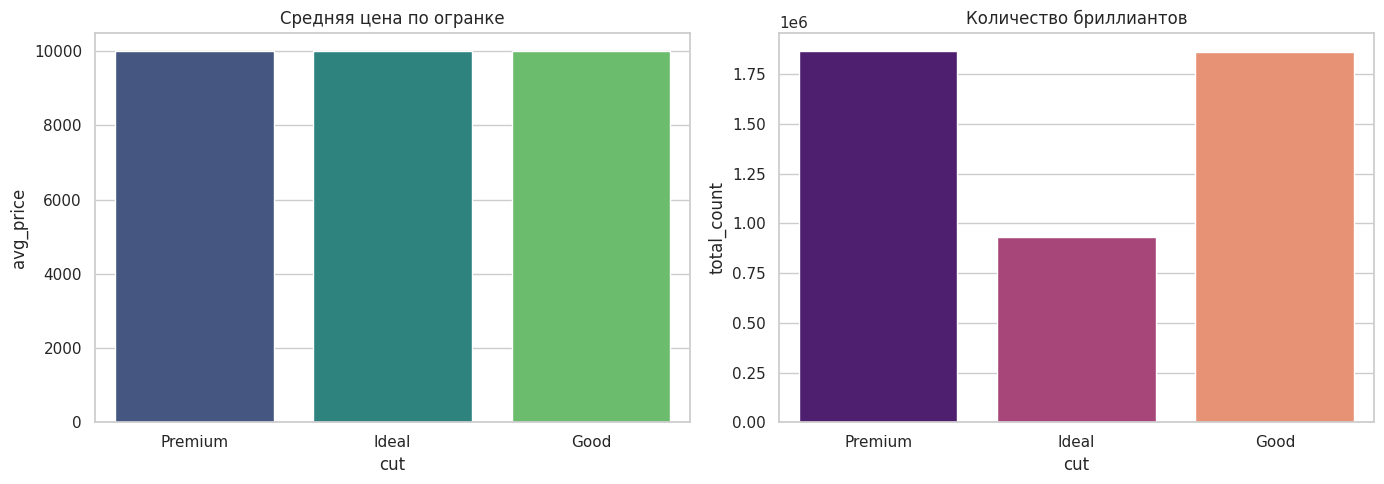

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

result_pd = result_spark.toPandas()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=result_pd, x='cut', y='avg_price', ax=axes[0], palette='viridis')
axes[0].set_title('Средняя цена по огранке')

sns.barplot(data=result_pd, x='cut', y='total_count', ax=axes[1], palette='magma')
axes[1].set_title('Количество бриллиантов')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1206/4095136964.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_pd, x='cut', y='avg_price', ax=axes[0], palette='viridis')
/tmp/ipykernel_1206/4095136964.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_pd, x='cut', y='total_count', ax=axes[1], palette='magma')


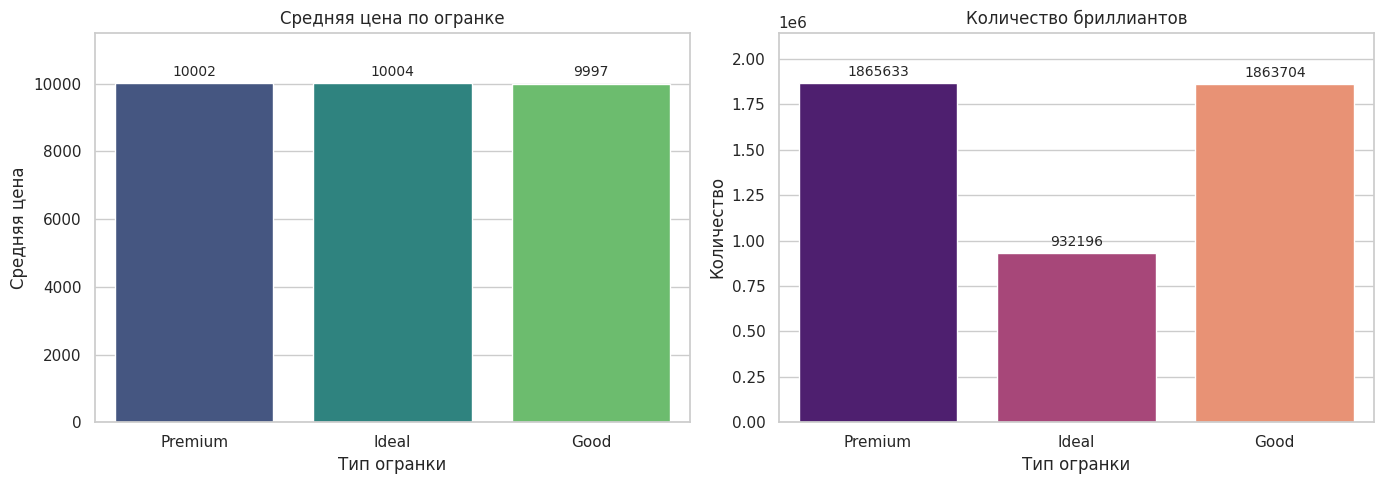

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

result_pd = result_spark.toPandas()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: средняя цена ---
sns.barplot(data=result_pd, x='cut', y='avg_price', ax=axes[0], palette='viridis')
axes[0].set_title('Средняя цена по огранке')
axes[0].set_xlabel('Тип огранки')
axes[0].set_ylabel('Средняя цена')
axes[0].set_ylim(0, result_pd['avg_price'].max() * 1.15)   # <-- Чтобы цифры над столбцом влезли

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3, fontsize=10)

# --- График 2: количество ---
sns.barplot(data=result_pd, x='cut', y='total_count', ax=axes[1], palette='magma')
axes[1].set_title('Количество бриллиантов')
axes[1].set_xlabel('Тип огранки')
axes[1].set_ylabel('Количество')
axes[1].set_ylim(0, result_pd['total_count'].max() * 1.15)  # <-- Чтобы цифры над столбцом влезли

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

## Вариант 2: Тот же запрос через Pandas но на 1 млн строк

In [ ]:
start_time = time.time()

# Аналогичный запрос на чистом Python/Pandas
result_pandas = df_pandas[
    (df_pandas['carat'] > 1.5) & (df_pandas['price'] > 5000)
]. groupby ('cut').agg(total_count = ('price', 'count'), avg_price = ('price', 'mean')). reset_index()

pandas_time = time.time() - start_time
print(f"Время выполнения Pandas: {pandas_time:.2f} секунд")
print("Результат:")
print(result_pandas)

Время выполнения Pandas: 0.12 секунд
Результат:
       cut  total_count     avg_price
0     Good       186293   9995.820033
1    Ideal        93114   9997.676107
2  Premium       186126  10005.890914
